In [413]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel
import lmfit

In [414]:
import sklearn
from sklearn.decomposition import PCA

In [415]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [416]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k/((freq-center)**2 + (k/2)**2)

In [417]:
def Gaussian(freq, amp, const, center, k):
    return const - amp*np.exp(-(freq-center)**2/(2*k**2))

In [418]:
header = "D:/K_sunada/result/CDY153/"
ac1037 = "/2023-12-29/2023-12-29T173725_7e58e084-cw_attenuation"
ac1033 = "/2023-12-29/2023-12-29T172638_fcb4636c-cw_attenuation"
ac1031 = "/2023-12-25/2023-12-25T162657_fc4e3f61-cw_attenuation"
ac1030 = "/2023-12-25/2023-12-25T153516_c43cbc37-cw_attenuation" 
ac1029 = "/2023-12-29/2023-12-29T171620_8c5c01d3-cw_attenuation"
ac1028 = "/2023-12-25/2023-12-25T155119_01ffdcb4-cw_attenuation"
ac1026 = "/2023-12-25/2023-12-25T160037_4ee6adc4-cw_attenuation"
ac1022 = "/2023-12-29/2023-12-29T181156_50a3e366-cw_attenuation"

dd1037 = datadict_from_hdf5(header + ac1037+"/data")
dd1033 = datadict_from_hdf5(header + ac1033+"/data")
dd1031 = datadict_from_hdf5(header + ac1031+"/data")
dd1030 = datadict_from_hdf5(header + ac1030+"/data")
dd1029 = datadict_from_hdf5(header + ac1029 +"/data")
dd1028 = datadict_from_hdf5(header + ac1028 +"/data")
dd1026 = datadict_from_hdf5(header + ac1026 +"/data")
dd1022 = datadict_from_hdf5(header + ac1022+"/data")

10.3 GHz

In [419]:
dd1031

s11: (21, 241)
  ⌙ frequency (Hz): (21, 241)
  ⌙ power (dBm): (21,)

In [477]:
y = np.unique(dd1031['power']['values'])
x = np.unique(dd1031['frequency']['values'])
z = np.real(dd1031['s11']['values'])

In [421]:
center1030_g = [7.9957e+09, 7.9938e+09, 7.9918e+09, 7.9901e+09, 7.9882e+09, 7.9861e+09, 7.9834e+09, 
              7.9813e+09, 7.9784e+09, 7.9760e+09, 7.9728e+09, 7.9703e+09, 7.9667e+09, 7.9632e+09, 
              7.9600e+09, 7.9560e+09, 7.9525e+09, 7.9484e+09, 7.9435e+09, 7.9408e+09, 7.9343e+09]

C:\Users\qipe\AppData\Local\Temp\ipykernel_4268\204718688.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


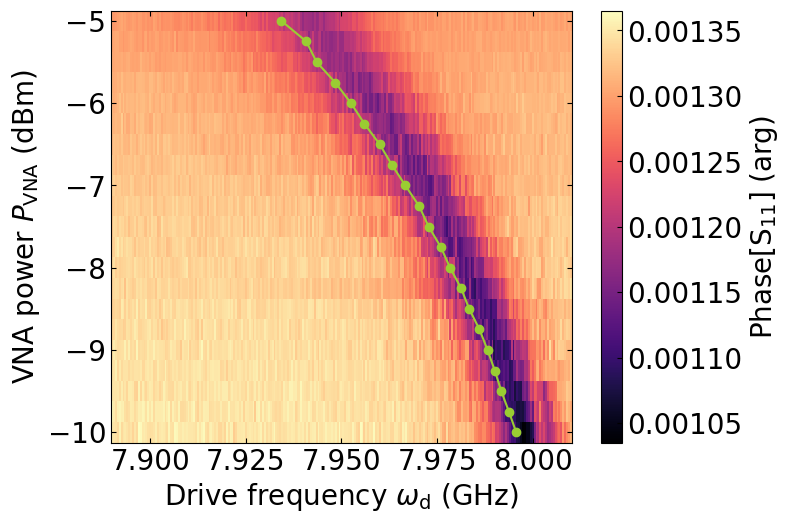

In [478]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_ylabel("VNA power $P_{\mathrm{VNA}}$ (dBm)")
ax.set_xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
# ax.set_xlim(-10, 20)
# ax.set_ylim(10, 10.6)

maingraph = ax.pcolormesh(x*1e-9,y, z.reshape(21, 241), vmin=min(np.unique(z)), vmax=max(np.unique(z)), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Phase[S$_{11}$] (arg)")
plt.tick_params(top='on',bottom='on',left='on',right='on')
plt.plot(np.array(center1030_g)*1e-9, y, '-o', color = 'yellowgreen')
# plt.savefig('ac_Stark.png', bbox_inches='tight')
plt.show()

In [423]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1030['frequency']['values'][i]
    y_real = dd1030['s11']['values'][i].real
    y_imag = dd1030['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

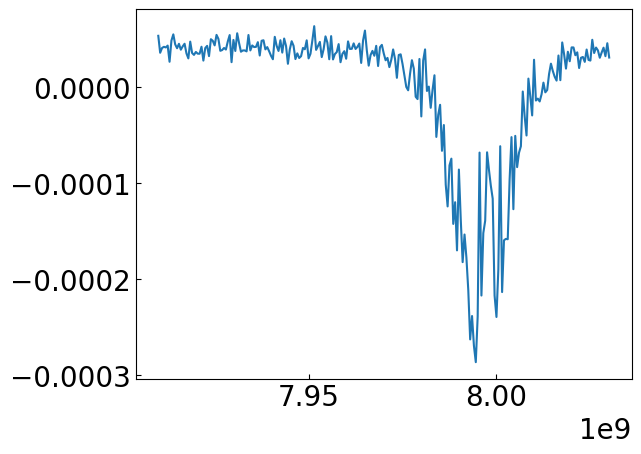

In [424]:
plt.plot(xs[0], ys[0])
plt.show()

In [425]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

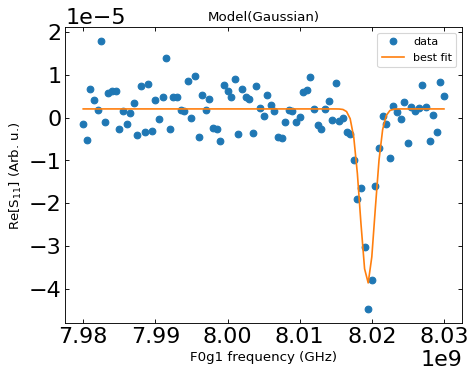

In [476]:
fig, ax = plt.subplots(dpi=80)
id = 10
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [427]:
center1030_g = [7.9957e+09, 7.9938e+09, 7.9918e+09, 7.9901e+09, 7.9882e+09, 7.9861e+09, 7.9834e+09, 
              7.9813e+09, 7.9784e+09, 7.9760e+09, 7.9728e+09, 7.9703e+09, 7.9667e+09, 7.9632e+09, 
              7.9600e+09, 7.9560e+09, 7.9525e+09, 7.9484e+09, 7.9435e+09, 7.9408e+09, 7.9343e+09]

In [428]:
center1030 = [7.9953e+09, 7.9935e+09, 7.9916e+09, 7.9901e+09, 7.9883e+09, 7.9862e+09, 7.9834e+09,
             7.9812e+09, 7.9784e+09, 7.9760e+09, 7.9728e+09, 7.9704e+09, 7.9667e+09, 7.9632e+09,
             7.9600e+09, 7.9562e+09, 7.9525e+09, 7.9485e+09, 7.9437e+09, 7.9409e+09, 7.9342e+09]

10.28 GHz

In [429]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1028['frequency']['values'][i]
    y_real = dd1028['s11']['values'][i].real
    y_imag = dd1028['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [430]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

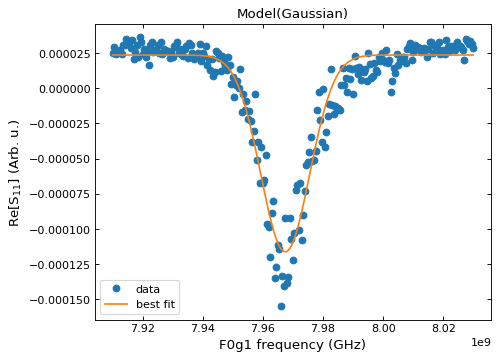

In [431]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [432]:
center1028_g = [8.0067e+09, 8.0052e+09, 8.0044e+09, 8.0035e+09, 8.0019e+09, 8.0004e+09, 7.9988e+09,
                7.9973e+09, 7.9953e+09, 7.9939e+09, 7.9917e+09, 7.9901e+09, 7.9882e+09, 7.9861e+09,
                7.9837e+09, 7.9811e+09, 7.9790e+09, 7.9763e+09, 7.9733e+09, 7.9709e+09, 7.9674e+09]

In [433]:
center1028 = [8.0070e+09, 8.0056e+09, 8.0048e+09, 8.0037e+09, 8.0019e+09, 8.0000e+09, 7.9983e+09,
              7.9968e+09, 7.9951e+09, 7.9936e+09, 7.9916e+09, 7.9900e+09, 7.9881e+09, 7.9859e+09,
              7.9838e+09, 7.9810e+09, 7.9789e+09, 7.9761e+09, 7.9731e+09, 7.9708e+09, 7.9673e+09]

10.26 GHz

In [434]:
xs = []
ys = []
num_of_freq = 181

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1026['frequency']['values'][i]
    y_real = dd1026['s11']['values'][i].real
    y_imag = dd1026['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [435]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

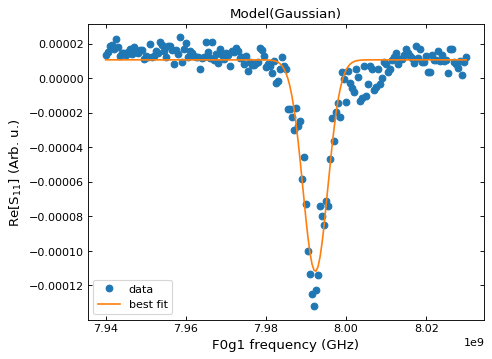

In [436]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [437]:
center1026_g = [8.0145e+09, 8.0141e+09, 8.0134e+09, 8.0127e+09, 8.0120e+09, 8.0113e+09, 8.0105e+09,
                8.0097e+09, 8.0089e+09, 8.0078e+09, 8.0070e+09, 8.0060e+09, 8.0048e+09, 8.0035e+09,
                8.0019e+09, 8.0011e+09, 7.9991e+09, 7.9977e+09, 7.9960e+09, 7.9938e+09, 7.9923e+09]

In [438]:
center1026 = [8.0145e+09, 8.0141e+09, 8.0133e+09, 8.0127e+09, 8.0120e+09, 8.0112e+09, 8.0105e+09,
            8.0097e+09, 8.0089e+09, 8.0078e+09, 8.0072e+09, 8.0063e+09, 8.0051e+09, 8.0037e+09,
            8.0018e+09, 8.0010e+09, 7.9989e+09, 7.9975e+09, 7.9956e+09, 7.9935e+09, 7.9923e+09]

10.22 GHz

In [439]:
xs = []
ys = []
num_of_freq = 101

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1022['frequency']['values'][i]
    y_real = dd1022['s11']['values'][i].real
    y_imag = dd1022['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [440]:
par_ini = {'amp': 0.00035,'const':0, 'center':8.0e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

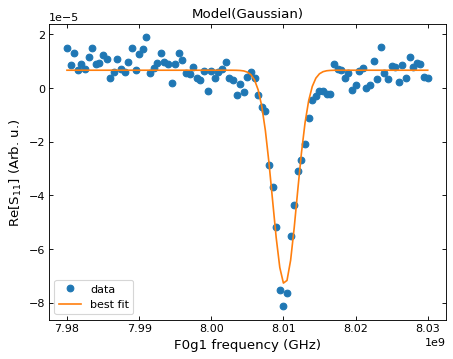

In [441]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [442]:
# center1022_g = [8.0199e+09, 8.0195e+09, 8.0191e+09, 8.0189e+09, 8.0187e+09, 8.0181e+09, 8.0179e+09,
#                 8.0175e+09, 8.0171e+09, 8.0167e+09, 8.0162e+09, 8.0157e+09, 8.0153e+09, 8.0147e+09,
#                 8.0142e+09, 8.0135e+09, 8.0129e+09, 8.0123e+09, 8.0116e+09, 8.0109e+09, 8.0102e+09]

In [443]:
center1022_g = [8.0172e+09, 8.0170e+09, 8.0163e+09, 8.0158e+09, 8.0153e+09, 8.0150e+09, 8.0144e+09,
                8.0137e+09, 8.0133e+09, 8.0126e+09, 8.0118e+09, 8.0110e+09, 8.0104e+09, 8.0091e+09,
                8.0083e+09, 8.0074e+09, 8.0065e+09, 8.0057e+09, 8.0041e+09, 8.0033e+09, 8.0021e+09]

10.31 GHz

In [444]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1031['frequency']['values'][i]
    y_real = dd1031['s11']['values'][i].real
    y_imag = dd1031['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [445]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.97e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

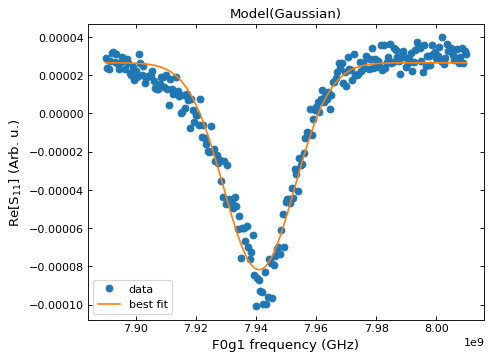

In [446]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [447]:
center1031_g = [7.9975e+09, 7.9959e+09, 7.9950e+09, 7.9923e+09, 7.9914e+09, 7.9886e+09, 7.9868e+09,
                7.9838e+09, 7.9821e+09, 7.9797e+09, 7.9772e+09, 7.9745e+09, 7.9710e+09, 7.9685e+09,
                7.9652e+09, 7.9614e+09, 7.9572e+09, 7.9537e+09, 7.9494e+09, 7.9456e+09, 7.9411e+09]

In [448]:
center1031 = [7.9975e+09, 7.9959e+09, 7.9949e+09, 7.9925e+09, 7.9915e+09, 7.9887e+09, 7.9870e+09,
              7.9841e+09, 7.9824e+09, 7.9797e+09, 7.9773e+09, 7.9745e+09, 7.9635e+09, 7.9686e+09,
              7.9652e+09, 7.9616e+09, 7.9575e+09, 7.9538e+09, 7.9495e+09, 7.9458e+09, 7.9413e+09]

10.29 GHz

In [449]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1029['frequency']['values'][i]
    y_real = dd1029['s11']['values'][i].real
    y_imag = dd1029['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [450]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.97e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

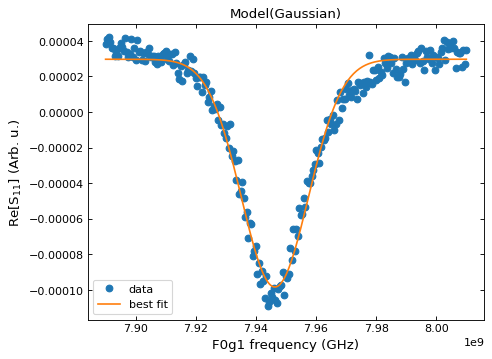

In [451]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [452]:
center1029_g = [7.9998e+09, 7.9983e+09, 7.9966e+09, 7.9950e+09, 7.9933e+09, 7.9914e+09, 7.9895e+09,
                7.9875e+09, 7.9852e+09, 7.9830e+09, 7.9804e+09, 7.9776e+09, 7.9749e+09, 7.9719e+09,
                7.9689e+09, 7.9654e+09, 7.9623e+09, 7.9584e+09, 7.9545e+09, 7.9506e+09, 7.9463e+09]

10.33 GHz

In [453]:
xs = []
ys = []
num_of_freq = 181

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1033['frequency']['values'][i]
    y_real = dd1033['s11']['values'][i].real
    y_imag = dd1033['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [454]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.98e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

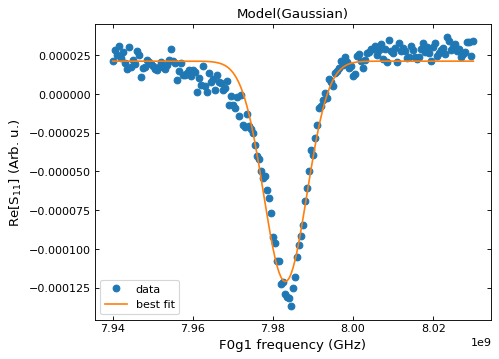

In [455]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [456]:
center1033_g = [8.0113e+09, 8.0105e+09, 8.0096e+09, 8.0087e+09, 8.0078e+09, 8.0069e+09, 8.0057e+09,
                8.0047e+09, 8.0036e+09, 8.0023e+09, 8.0010e+09, 7.9996e+09, 7.9982e+09, 7.9967e+09,
                7.9950e+09, 7.9931e+09, 7.9915e+09, 7.9896e+09, 7.9876e+09, 7.9853e+09, 7.9831e+09]

10.37 GHz

In [457]:
xs = []
ys = []
num_of_freq = 101

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1037['frequency']['values'][i]
    y_real = dd1037['s11']['values'][i].real
    y_imag = dd1037['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [458]:
par_ini = {'amp': 0.00035,'const':0, 'center':8.02e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

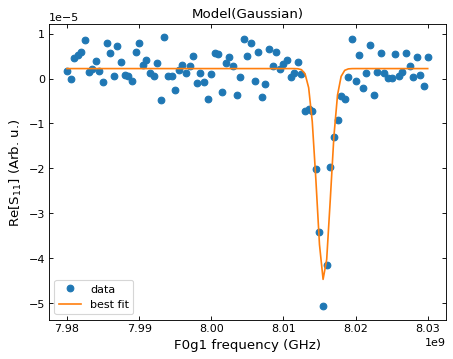

In [459]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [460]:
center1037_g = [8.0214e+09, 8.0214e+09, 8.0212e+09, 8.0210e+09, 8.0208e+09, 8.0207e+09, 8.0203e+09,
                8.0202e+09, 8.0198e+09, 8.0196e+09, 8.0194e+09, 8.0192e+09, 8.0188e+09, 8.0184e+09,
                8.0181e+09, 8.0179e+09, 8.0173e+09, 8.0169e+09, 8.0166e+09, 8.0161e+09, 8.0156e+09]

In [461]:
power_dBm = np.linspace(-10, -5, 21)
power_W = 10**((power_dBm)/10) *1e-3

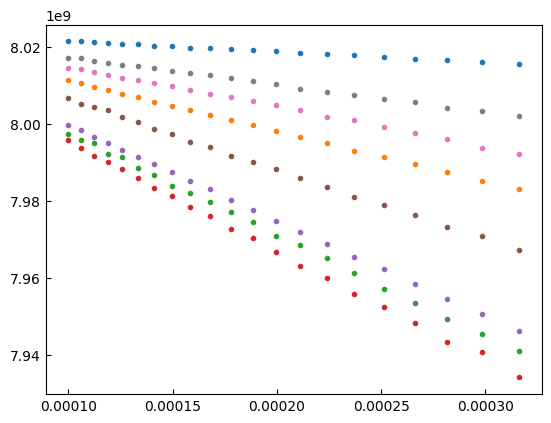

In [462]:
plt.plot(power_W, center1037_g, '.', label="10.37 GHz")
plt.plot(power_W, center1033_g, '.', label="10.33 GHz")
plt.plot(power_W, center1031_g, '.', label="10.31 GHz")
plt.plot(power_W, center1030_g, '.', label="10.30 GHz")
plt.plot(power_W, center1029_g, '.', label="10.29 GHz")
plt.plot(power_W, center1028_g, '.', label="10.28 GHz")
plt.plot(power_W, center1026_g, '.', label="10.26 GHz")
plt.plot(power_W, center1022_g, '.', label="10.22 GHz")

plt.show()

In [463]:
def liner_func(power, alpha, const):
    return const - alpha*power

In [464]:
par_ini = {'alpha': 0.015e9/0.00005,'const':8.005e9}
par_min = {'alpha': -np.inf,'const':-np.inf}
par_max = {'alpha': np.inf,'const':np.inf}
par_vary = {'alpha': True,'const':True}
model = lmfit.Model(liner_func)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result1037 = model.fit(data = center1037_g, params=params, power = power_W)
result1033 = model.fit(data = center1033_g, params=params, power = power_W)
result1031 = model.fit(data = center1031_g, params=params, power = power_W)
result1030 = model.fit(data = center1030_g, params=params, power = power_W)
result1029 = model.fit(data = center1029_g, params=params, power = power_W)
result1028 = model.fit(data = center1028_g, params=params, power = power_W)
result1026 = model.fit(data = center1026_g, params=params, power = power_W)
result1022 = model.fit(data = center1022_g, params=params, power = power_W)

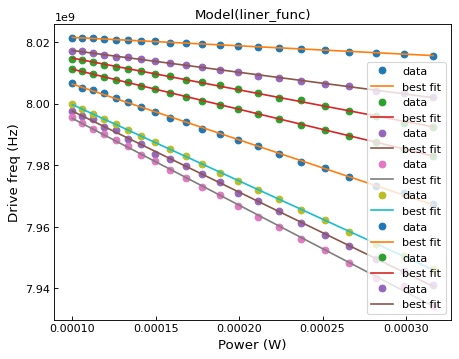

In [465]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
result1037.plot_fit(ax = ax)
result1033.plot_fit(ax = ax)
result1031.plot_fit(ax = ax)
result1030.plot_fit(ax = ax)
result1029.plot_fit(ax = ax)
result1028.plot_fit(ax = ax)
result1026.plot_fit(ax = ax)
result1022.plot_fit(ax = ax)
ax.set_xlabel('Power (W)', size='large')
ax.set_ylabel('Drive freq (Hz)', size='large')
plt.legend()
plt.show()
result1022

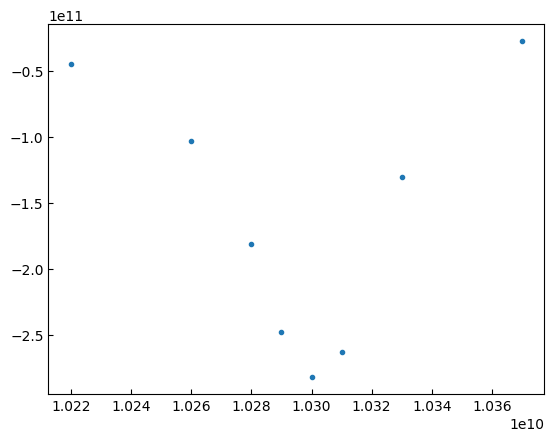

In [466]:
x = np.array([10.37e9, 10.33e9, 10.31e9, 10.30e9,10.29e9, 10.28e9, 10.26e9, 10.22e9])
alpha = np.array([-2.7268e+10, -1.3029e+11, -2.6321e+11, -2.8213e+11, -2.4807e+11,  -1.8144e+11, -1.0320e+11, -4.4706e+10])
plt.plot(x, alpha, '.')
plt.show()

In [467]:
from scipy.constants import *

In [468]:
# k_sunada - dpr model
# k_f =0.21238950e9
chi_Hz = -2000000.0
chi = chi_Hz*2*np.pi

# omega_p =np.array([10.37e9, 10.33e9, 10.31e9, 10.30e9,10.29e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi
# omega_f = 10.1676834e9 *2*np.pi
# omega_r =10.2557302e9*2*np.pi
omega_p=np.array([10.31e9, 10.30e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi

# g = 0.1011e9
# slope= np.array([-2.7268e+10, -1.3029e+11, -2.6321e+11, -2.8213e+11, -2.4807e+11,  -1.8144e+11, -1.0320e+11, -4.4706e+10])*2*np.pi
slope= np.array([-2.6321e+11, -2.8213e+11,  -1.8144e+11, -1.0320e+11, -7.0833e+10])*2*np.pi
P = 0.0002
# P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5
Delta_q = np.array(slope*P * 2*np.pi)
# delta_f = omega_p-omega_f
# delta_r = omega_p-omega_r

def coeff2(k_f, delta_r, delta_f, g):
    numer = k_f *g**2/(delta_r**2)
    denom = (delta_f - g**2/delta_r)**2 +(k_f/2)**2
    return numer/denom

def ac_stark_shift1(omega,  omega_r, omega_f, k_f, g, alpha):
    return 2*chi*alpha/(hbar*omega)*coeff2(k_f=k_f, delta_r=omega-omega_r, delta_f=omega-omega_f, g=g)

In [469]:
# x=np.array([10.37e9, 10.33e9, 10.31e9, 10.30e9,10.29e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi
# slope= np.array([-2.7268e+10, -1.3029e+11, -2.6321e+11, -2.8213e+11, -2.4807e+11,  -1.8144e+11, -1.0320e+11, -4.4706e+10])*2*np.pi

x=np.array([10.31e9, 10.30e9, 10.28e9, 10.26e9,10.22e9])*2*np.pi
slope= np.array([-2.6321e+11, -2.8213e+11, -1.8144e+11, -1.0320e+11,-7.0833e+10])*2*np.pi
par_ini = {'omega_r':10.267e9*2*np.pi, 'omega_f':10.192e9*2*np.pi,
           'k_f':0.23e9*2*np.pi,'g':0.087e9*2*np.pi, 'alpha':4.4e-11}
par_min = {'omega_r':0, 'omega_f':0,'k_f':0,'g':0, 'alpha':0}
par_max = {'omega_r':np.inf,'omega_f':np.inf, 'k_f':np.inf,'g':np.inf, 'alpha':np.inf}
par_vary = { 'omega_r':False,'omega_f':False, 'k_f':True,'g':True, 'alpha':True}
model = lmfit.Model(ac_stark_shift1)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = slope, params=params, omega =x )

ValueError: x and y must have same first dimension, but have shapes (241,) and (5,)

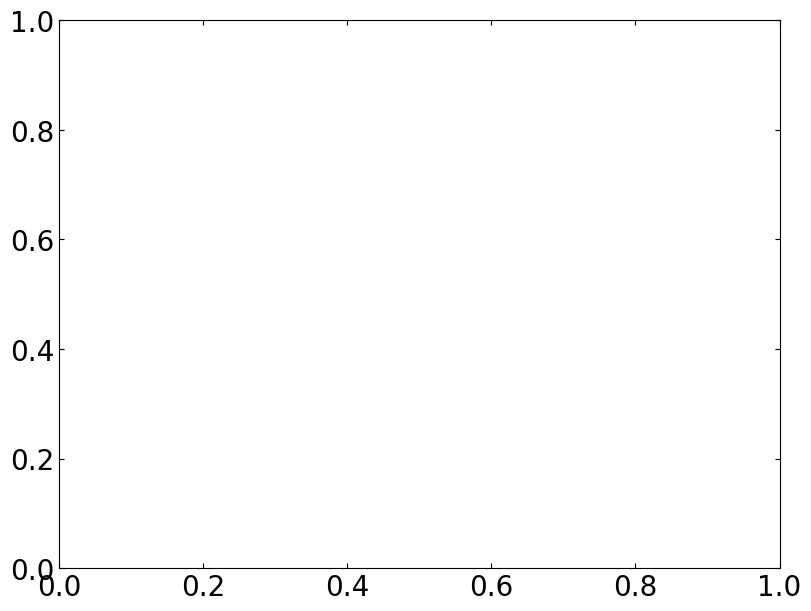

In [479]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

# result.plot_fit(ax = ax)# result = model.fit(y, params, x=x)
x_interp = np.linspace(10.22e9, 10.31e9, 100*5)*2*np.pi
y_interp = result.model.func(x_interp, **result.best_values)

plt.plot(x/(2*np.pi)*1e-9, slope/(2*np.pi)*1e-9,'o', label='original')
plt.plot(x_interp/(2*np.pi)*1e-9, y_interp/(2*np.pi)*1e-9, label='interpolated')
# ax.plot(x/(2*np.pi)*1e-9,result.init_fit/(2*np.pi)*1e-9)
ax.set_xlabel('Probe frequency $\omega_\mathrm{p}$ (GHz)', size='large')
ax.set_ylabel('Shift $\Delta_\mathrm{ac}$ / VNA power $P_\mathrm{VNA}$ (GHz/W)')
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.savefig('slope.png', bbox_inches='tight')
plt.show()

result

In [471]:
6.4503e+10/(2*np.pi),6.4038e+10/(2*np.pi),1.2261e+09/(2*np.pi),4.9860e+08	/(2*np.pi)

(10265971294.256525, 10191964245.718794, 195139875.72497287, 79354654.62561902)

In [472]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [473]:
watt_dbm(4.3951e-11*1e-3) + 50


-53.570312391444475

n_crit, n_ave

(10250000000.0, 10350000000.0)

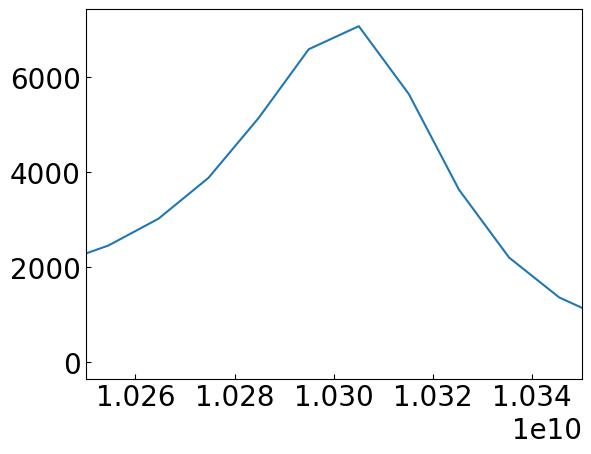

In [474]:
omega = np.linspace(9.8, 10.8, 100)*1e9*2*np.pi
k_f = 1.2261e+09
omega_f = 6.4038e+10
omega_r = 6.4509e+10
g = 4.9860e+08
alpha = 4.3951e-11
Power = dbm_watt(20)
n_ave = alpha*Power/(hbar*omega)*coeff2(k_f=k_f, delta_r=omega-omega_r, delta_f=omega-omega_f, g=g)
plt.plot(omega/(2*np.pi), n_ave)
plt.xlim(10.25e9, 10.35e9)

In [475]:
omega_q = 8.0241e9*2*np.pi
delta = omega_q-omega_r
omega_r = 6.4509e+10
g = 4.9860e+08


n_crit = delta**2/(2*g)**2
delta, n_crit

(-14092092776.660278, 199.7038547342917)